In [36]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns
import seaborn.objects as so
import numpy as np
import gc
from datetime import datetime, timezone
import geopandas as gpd
import geodatasets
from shapely.geometry import Point
from shapely.geometry import MultiPolygon
from scipy import stats

In [2]:
os.listdir("/Users/25298423/Downloads/ICESDataPortalDownload_Ocean_00f37a9f-c554-4002-ae0b-e71772e901d5_unzipped_bottledata_1877onwards_20W_2W")

['f60c1cb6-8346-46c1-adb3-250ff4d9c502.csv',
 'f60c1cb6-8346-46c1-adb3-250ff4d9c502_Criteria.json',
 'f60c1cb6-8346-46c1-adb3-250ff4d9c502_Disclaimer.txt']

In [3]:
ices_data = pd.read_csv("/Users/25298423/Downloads/ICESDataPortalDownload_Ocean_00f37a9f-c554-4002-ae0b-e71772e901d5_unzipped_bottledata_1877onwards_20W_2W/f60c1cb6-8346-46c1-adb3-250ff4d9c502.csv", skiprows=19, dtype={'Cruise': str, 'Station':str})

In [4]:
ices_data

,Cruise,Station,Type,yyyy-mm-ddThh:mm:ss.sss,Latitude [degrees_north],Longitude [degrees_east],Bot. Depth [m],Secchi Depth [m],Device Category Code (L05):METAVAR:TEXT,Platform Code (C17):METAVAR:TEXT,...,pH (PHXXZZXX_UUPH) [pH units],QV:ODV:pH (PHXXZZXX_UUPH),Total Alkalinity (ALKYZZXX_MEQL) [mEq/l],QV:ODV:Total Alkalinity (ALKYZZXX_MEQL),Chlorophyll a (CPHLZZXX_UGPL) [ug/l],QV:ODV:Chlorophyll a (CPHLZZXX_UGPL),Turbidity (TURBXXXX_USTU) [NTU],QV:ODV:Turbidity (TURBXXXX_USTU),Phaeophytin a (PTAXZZXX_UGPL) [ug/l],QV:ODV:Phaeophytin a (PTAXZZXX_UGPL)
0,11BE,2116,*,1993-04-20T11:05Z,50.40080,-2.014700,44.0,NaN,30,11BE,...,NaN,NaN,NaN,NaN,1.50,0.0,NaN,NaN,NaN,NaN
1,11BE,2118,*,1993-04-20T14:33Z,50.16670,-3.007800,63.0,NaN,30,11BE,...,NaN,NaN,NaN,NaN,4.00,0.0,NaN,NaN,NaN,NaN
2,11BE,2120,*,1993-04-20T21:04Z,49.66780,-4.497500,83.0,NaN,30,11BE,...,NaN,NaN,NaN,NaN,1.60,0.0,NaN,NaN,NaN,NaN
3,11BE,2122,*,1993-04-21T04:20Z,49.00200,-5.992700,122.0,NaN,30,11BE,...,NaN,NaN,NaN,NaN,3.10,0.0,NaN,NaN,NaN,NaN
4,11BE,3194,*,1993-05-04T10:58Z,48.66450,-5.012200,108.0,NaN,30,11BE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1032972,CW_2024,040-P-017-2024-02-05T12:00Z,*,2024-02-05T12:00Z,48.10991,-4.298194,11.0,NaN,30,ZZ99,...,NaN,NaN,NaN,NaN,2.20,1.0,0.05,1.0,NaN,NaN
1032973,CW_2024,040-P-017-2024-02-19T13:30Z,*,2024-02-19T13:30Z,48.10991,-4.298194,11.0,NaN,30,ZZ99,...,NaN,NaN,NaN,NaN,1.09,1.0,1.90,1.0,NaN,NaN
1032974,CW_2024,040-P-017-2024-03-04T09:50Z,*,2024-03-04T09:50Z,48.10991,-4.298194,11.0,NaN,30,ZZ99,...,NaN,NaN,NaN,NaN,0.62,1.0,3.90,1.0,NaN,NaN
1032975,CW_2024,040-P-017-2024-04-03T10:45Z,*,2024-04-03T10:45Z,48.10991,-4.298194,11.0,NaN,30,ZZ99,...,NaN,NaN,NaN,NaN,0.81,1.0,0.90,1.0,NaN,NaN


In [5]:
ices_data.columns

Index(['Cruise', 'Station', 'Type', 'yyyy-mm-ddThh:mm:ss.sss',
       'Latitude [degrees_north]', 'Longitude [degrees_east]',
       'Bot. Depth [m]', 'Secchi Depth [m]',
       'Device Category Code (L05):METAVAR:TEXT',
       'Platform Code (C17):METAVAR:TEXT',
       'Custodian Code (EDMO):METAVAR:TEXT',
       'Originator Code (EDMO):METAVAR:TEXT',
       'Distributor Code (EDMO):METAVAR:TEXT',
       'Project Code (EDMERP):METAVAR:TEXT', 'Modified:METAVAR:TEXT',
       'GUID:METAVAR:TEXT', 'Depth (ADEPZZ01_ULAA) [m]',
       'QV:ODV:Depth (ADEPZZ01_ULAA)', 'Temperature (TEMPPR01_UPAA) [degC]',
       'QV:ODV:Temperature (TEMPPR01_UPAA)',
       'Salinity (PSALPR01_UUUU) [dmnless]', 'QV:ODV:Salinity (PSALPR01_UUUU)',
       'Oxygen (DOXYZZXX_UMLL) [ml/l]', 'QV:ODV:Oxygen (DOXYZZXX_UMLL)',
       'Phosphate (PHOSZZXX_UPOX) [umol/l]',
       'QV:ODV:Phosphate (PHOSZZXX_UPOX)',
       'Total Phosphorus (TPHSZZXX_UPOX) [umol/l]',
       'QV:ODV:Total Phosphorus (TPHSZZXX_UPOX)',
      

In [6]:
ices_data = ices_data[['Cruise','Station','yyyy-mm-ddThh:mm:ss.sss', 'Latitude [degrees_north]','Longitude [degrees_east]','Bot. Depth [m]','Secchi Depth [m]','Depth (ADEPZZ01_ULAA) [m]','Temperature (TEMPPR01_UPAA) [degC]','Salinity (PSALPR01_UUUU) [dmnless]','Oxygen (DOXYZZXX_UMLL) [ml/l]','Phosphate (PHOSZZXX_UPOX) [umol/l]','Total Phosphorus (TPHSZZXX_UPOX) [umol/l]', 'Silicate (SLCAZZXX_UPOX) [umol/l]','Nitrate + Nitrite (NTRZZZXX_UPOX) [umol/l]',  'Nitrate (NTRAZZXX_UPOX) [umol/l]', 'Nitrite (NTRIZZXX_UPOX) [umol/l]', 'Ammonium (AMONZZXX_UPOX) [umol/l]','Total Nitrogen (NTOTZZXX_UPOX) [umol/l]', 'pH (PHXXZZXX_UUPH) [pH units]',  'Total Alkalinity (ALKYZZXX_MEQL) [mEq/l]', 'Chlorophyll a (CPHLZZXX_UGPL) [ug/l]', 'Turbidity (TURBXXXX_USTU) [NTU]','Phaeophytin a (PTAXZZXX_UGPL) [ug/l]',]]

In [7]:
ices_data

,Cruise,Station,yyyy-mm-ddThh:mm:ss.sss,Latitude [degrees_north],Longitude [degrees_east],Bot. Depth [m],Secchi Depth [m],Depth (ADEPZZ01_ULAA) [m],Temperature (TEMPPR01_UPAA) [degC],Salinity (PSALPR01_UUUU) [dmnless],...,Nitrate + Nitrite (NTRZZZXX_UPOX) [umol/l],Nitrate (NTRAZZXX_UPOX) [umol/l],Nitrite (NTRIZZXX_UPOX) [umol/l],Ammonium (AMONZZXX_UPOX) [umol/l],Total Nitrogen (NTOTZZXX_UPOX) [umol/l],pH (PHXXZZXX_UUPH) [pH units],Total Alkalinity (ALKYZZXX_MEQL) [mEq/l],Chlorophyll a (CPHLZZXX_UGPL) [ug/l],Turbidity (TURBXXXX_USTU) [NTU],Phaeophytin a (PTAXZZXX_UGPL) [ug/l]
0,11BE,2116,1993-04-20T11:05Z,50.40080,-2.014700,44.0,NaN,0.000000,NaN,NaN,...,NaN,0.7,0.14,NaN,NaN,NaN,NaN,1.50,NaN,NaN
1,11BE,2118,1993-04-20T14:33Z,50.16670,-3.007800,63.0,NaN,0.000000,NaN,NaN,...,NaN,0.3,0.17,NaN,NaN,NaN,NaN,4.00,NaN,NaN
2,11BE,2120,1993-04-20T21:04Z,49.66780,-4.497500,83.0,NaN,0.000000,NaN,NaN,...,NaN,0.6,0.20,NaN,NaN,NaN,NaN,1.60,NaN,NaN
3,11BE,2122,1993-04-21T04:20Z,49.00200,-5.992700,122.0,NaN,0.000000,NaN,NaN,...,NaN,0.2,0.14,NaN,NaN,NaN,NaN,3.10,NaN,NaN
4,11BE,3194,1993-05-04T10:58Z,48.66450,-5.012200,108.0,NaN,1.487319,11.788,35.295,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1032972,CW_2024,040-P-017-2024-02-05T12:00Z,2024-02-05T12:00Z,48.10991,-4.298194,11.0,NaN,1.000000,10.670,33.860,...,16.4,NaN,NaN,0.31,NaN,NaN,NaN,2.20,0.05,NaN
1032973,CW_2024,040-P-017-2024-02-19T13:30Z,2024-02-19T13:30Z,48.10991,-4.298194,11.0,NaN,1.000000,11.400,32.500,...,25.0,NaN,NaN,0.64,NaN,NaN,NaN,1.09,1.90,NaN
1032974,CW_2024,040-P-017-2024-03-04T09:50Z,2024-03-04T09:50Z,48.10991,-4.298194,11.0,NaN,1.000000,10.200,32.600,...,17.7,NaN,NaN,0.39,NaN,NaN,NaN,0.62,3.90,NaN
1032975,CW_2024,040-P-017-2024-04-03T10:45Z,2024-04-03T10:45Z,48.10991,-4.298194,11.0,NaN,1.000000,11.430,33.900,...,6.6,NaN,NaN,0.75,NaN,NaN,NaN,0.81,0.90,NaN


In [94]:
clean_ices_column_names = ['cruise','station','time','latitude_degN','longitude_degE','bottom_depth_m','secchi_depth_m','depth','temp_degC','salinity','oxygen_ml_l','phosphate_umol_l','total_P_umol_l','silicate_umol_l','nitrate+nitrite_umol_l','nitrate_umol_l','nitrite_umol_l','ammonium_umol_l','total_n_umol_l','pH_phunits','total_alk_meq/l','chlorophylla_ug_l','turbidity_ntu','phaeophytina_ug_l']

In [95]:
len(clean_ices_column_names) ==len(ices_data.columns)

True

In [96]:
ices_data.columns=clean_ices_column_names
ices_data

,cruise,station,time,latitude_degN,longitude_degE,bottom_depth_m,secchi_depth_m,depth,temp_degC,salinity,...,nitrate+nitrite_umol_l,nitrate_umol_l,nitrite_umol_l,ammonium_umol_l,total_n_umol_l,pH_phunits,total_alk_meq/l,chlorophylla_ug_l,turbidity_ntu,phaeophytina_ug_l
0,11BE,2116,1993-04-20T11:05Z,50.40080,-2.014700,44.0,NaN,0.000000,NaN,NaN,...,NaN,0.7,0.14,NaN,NaN,NaN,NaN,1.50,NaN,NaN
1,11BE,2118,1993-04-20T14:33Z,50.16670,-3.007800,63.0,NaN,0.000000,NaN,NaN,...,NaN,0.3,0.17,NaN,NaN,NaN,NaN,4.00,NaN,NaN
2,11BE,2120,1993-04-20T21:04Z,49.66780,-4.497500,83.0,NaN,0.000000,NaN,NaN,...,NaN,0.6,0.20,NaN,NaN,NaN,NaN,1.60,NaN,NaN
3,11BE,2122,1993-04-21T04:20Z,49.00200,-5.992700,122.0,NaN,0.000000,NaN,NaN,...,NaN,0.2,0.14,NaN,NaN,NaN,NaN,3.10,NaN,NaN
4,11BE,3194,1993-05-04T10:58Z,48.66450,-5.012200,108.0,NaN,1.487319,11.788,35.295,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1032972,CW_2024,040-P-017-2024-02-05T12:00Z,2024-02-05T12:00Z,48.10991,-4.298194,11.0,NaN,1.000000,10.670,33.860,...,16.4,NaN,NaN,0.31,NaN,NaN,NaN,2.20,0.05,NaN
1032973,CW_2024,040-P-017-2024-02-19T13:30Z,2024-02-19T13:30Z,48.10991,-4.298194,11.0,NaN,1.000000,11.400,32.500,...,25.0,NaN,NaN,0.64,NaN,NaN,NaN,1.09,1.90,NaN
1032974,CW_2024,040-P-017-2024-03-04T09:50Z,2024-03-04T09:50Z,48.10991,-4.298194,11.0,NaN,1.000000,10.200,32.600,...,17.7,NaN,NaN,0.39,NaN,NaN,NaN,0.62,3.90,NaN
1032975,CW_2024,040-P-017-2024-04-03T10:45Z,2024-04-03T10:45Z,48.10991,-4.298194,11.0,NaN,1.000000,11.430,33.900,...,6.6,NaN,NaN,0.75,NaN,NaN,NaN,0.81,0.90,NaN


In [97]:
secchi_data = ices_data[ices_data['secchi_depth_m'].notna()].copy()
secchi_data

,cruise,station,time,latitude_degN,longitude_degE,bottom_depth_m,secchi_depth_m,depth,temp_degC,salinity,...,nitrate+nitrite_umol_l,nitrate_umol_l,nitrite_umol_l,ammonium_umol_l,total_n_umol_l,pH_phunits,total_alk_meq/l,chlorophylla_ug_l,turbidity_ntu,phaeophytina_ug_l
163488,4599,1331,2007-02-21T13:31Z,51.4838,-9.374800,3.0,1.0,0.0,8.69,29.68,...,NaN,29.3,NaN,12.9,NaN,8.08,NaN,2.4,NaN,NaN
163489,4599,1331,2007-02-21T13:31Z,51.4838,-9.374800,3.0,1.0,2.0,NaN,34.15,...,NaN,18.6,NaN,17.1,NaN,8.06,NaN,6.1,NaN,NaN
163492,4599,1430,2007-06-26T14:30Z,51.4838,-9.374800,5.0,2.5,0.0,14.67,33.88,...,NaN,0.7,NaN,1.4,NaN,8.18,NaN,2.0,NaN,NaN
163493,4599,1430,2007-06-26T14:30Z,51.4838,-9.374800,5.0,2.5,5.0,14.52,34.08,...,NaN,0.7,NaN,1.4,NaN,8.18,NaN,1.8,NaN,NaN
163494,4599,1100,2007-08-14T11:00Z,51.4838,-9.374800,4.0,2.6,0.0,14.43,33.68,...,NaN,0.7,NaN,4.3,NaN,8.10,NaN,2.9,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1032659,BSHG#2022#067I#20220719,GN045B_20220805T153800Z,2022-08-05T15:38Z,58.5000,-2.500000,72.0,9.5,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1032661,BSHG#2022#067I#20220719,GN056C_20220806T073200Z,2022-08-06T07:32Z,58.3330,-5.667000,106.0,10.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1032662,BSHG#2022#067I#20220719,GN064_20220806T104800Z,2022-08-06T10:48Z,58.0000,-6.000000,65.0,9.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1032964,BSHG#2024#067I#20240723,GN045A_20240811T112400Z,2024-08-11T11:24Z,58.0000,-2.000000,85.0,9.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [98]:
secchi_data.reset_index(inplace=True, drop=True)
secchi_data

,cruise,station,time,latitude_degN,longitude_degE,bottom_depth_m,secchi_depth_m,depth,temp_degC,salinity,...,nitrate+nitrite_umol_l,nitrate_umol_l,nitrite_umol_l,ammonium_umol_l,total_n_umol_l,pH_phunits,total_alk_meq/l,chlorophylla_ug_l,turbidity_ntu,phaeophytina_ug_l
0,4599,1331,2007-02-21T13:31Z,51.4838,-9.374800,3.0,1.0,0.0,8.69,29.68,...,NaN,29.3,NaN,12.9,NaN,8.08,NaN,2.4,NaN,NaN
1,4599,1331,2007-02-21T13:31Z,51.4838,-9.374800,3.0,1.0,2.0,NaN,34.15,...,NaN,18.6,NaN,17.1,NaN,8.06,NaN,6.1,NaN,NaN
2,4599,1430,2007-06-26T14:30Z,51.4838,-9.374800,5.0,2.5,0.0,14.67,33.88,...,NaN,0.7,NaN,1.4,NaN,8.18,NaN,2.0,NaN,NaN
3,4599,1430,2007-06-26T14:30Z,51.4838,-9.374800,5.0,2.5,5.0,14.52,34.08,...,NaN,0.7,NaN,1.4,NaN,8.18,NaN,1.8,NaN,NaN
4,4599,1100,2007-08-14T11:00Z,51.4838,-9.374800,4.0,2.6,0.0,14.43,33.68,...,NaN,0.7,NaN,4.3,NaN,8.10,NaN,2.9,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38184,BSHG#2022#067I#20220719,GN045B_20220805T153800Z,2022-08-05T15:38Z,58.5000,-2.500000,72.0,9.5,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
38185,BSHG#2022#067I#20220719,GN056C_20220806T073200Z,2022-08-06T07:32Z,58.3330,-5.667000,106.0,10.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
38186,BSHG#2022#067I#20220719,GN064_20220806T104800Z,2022-08-06T10:48Z,58.0000,-6.000000,65.0,9.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
38187,BSHG#2024#067I#20240723,GN045A_20240811T112400Z,2024-08-11T11:24Z,58.0000,-2.000000,85.0,9.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [99]:
len(secchi_data)

38189

In [100]:
secchi_data.dtypes

cruise                     object
station                    object
time                       object
latitude_degN             float64
longitude_degE            float64
bottom_depth_m            float64
secchi_depth_m            float64
depth                     float64
temp_degC                 float64
salinity                  float64
oxygen_ml_l               float64
phosphate_umol_l          float64
total_P_umol_l            float64
silicate_umol_l           float64
nitrate+nitrite_umol_l    float64
nitrate_umol_l            float64
nitrite_umol_l            float64
ammonium_umol_l           float64
total_n_umol_l            float64
pH_phunits                float64
total_alk_meq/l           float64
chlorophylla_ug_l         float64
turbidity_ntu             float64
phaeophytina_ug_l         float64
dtype: object

In [101]:
## the "Z" at the end of the date/time tells us that is is in UTC. Keep it that way.
secchi_data['time'] = pd.to_datetime(secchi_data['time'], format='mixed',utc=True)
secchi_data.dtypes

cruise                                 object
station                                object
time                      datetime64[ns, UTC]
latitude_degN                         float64
longitude_degE                        float64
bottom_depth_m                        float64
secchi_depth_m                        float64
depth                                 float64
temp_degC                             float64
salinity                              float64
oxygen_ml_l                           float64
phosphate_umol_l                      float64
total_P_umol_l                        float64
silicate_umol_l                       float64
nitrate+nitrite_umol_l                float64
nitrate_umol_l                        float64
nitrite_umol_l                        float64
ammonium_umol_l                       float64
total_n_umol_l                        float64
pH_phunits                            float64
total_alk_meq/l                       float64
chlorophylla_ug_l                 

## Need to go through and remove duplicate values for the same exact lat/long combo on the same days by the same cruise on the same station.

In [102]:
## See which is better, just taking the first value, or taking the mean value
secchi_data.groupby(['cruise','station','time','longitude_degE','latitude_degN'])['secchi_depth_m'].first().reset_index()

,cruise,station,time,longitude_degE,latitude_degN,secchi_depth_m
0,411,1001-1,2022-03-02 16:36:00+00:00,-8.612848,51.722961,0.30
1,411,1001-1,2023-02-02 14:43:00+00:00,-8.612850,51.722960,2.25
2,411,1001-2,2022-05-16 07:26:00+00:00,-8.612848,51.722961,1.00
3,411,1001-2,2023-06-22 09:41:00+00:00,-8.612850,51.722960,1.25
4,411,1001-3,2022-07-06 11:53:00+00:00,-8.612848,51.722961,1.25
...,...,...,...,...,...,...
19813,MIGR#BSHG#2005#06G2#20050810#20050164,GN905_20050813T0552Z,2005-08-13 05:52:00+00:00,-4.000000,49.833332,7.00
19814,MIGR#BSHG#2005#06G2#20050810#20050164,GN906_20050813T1615Z,2005-08-13 16:15:00+00:00,-6.000000,49.000000,9.00
19815,MIGR#BSHG#2005#06G2#20050810#20050164,GN907_20050813T2206Z,2005-08-13 22:06:00+00:00,-5.000000,48.666668,7.00
19816,MIGR#BSHG#2005#06G2#20050810#20050164,GN908_20050814T0750Z,2005-08-14 07:50:00+00:00,-3.000000,49.500000,8.50


In [103]:
secchi_data.groupby(['cruise','station','time','longitude_degE','latitude_degN'])['secchi_depth_m'].mean().reset_index()

,cruise,station,time,longitude_degE,latitude_degN,secchi_depth_m
0,411,1001-1,2022-03-02 16:36:00+00:00,-8.612848,51.722961,0.30
1,411,1001-1,2023-02-02 14:43:00+00:00,-8.612850,51.722960,2.25
2,411,1001-2,2022-05-16 07:26:00+00:00,-8.612848,51.722961,1.00
3,411,1001-2,2023-06-22 09:41:00+00:00,-8.612850,51.722960,1.25
4,411,1001-3,2022-07-06 11:53:00+00:00,-8.612848,51.722961,1.25
...,...,...,...,...,...,...
19813,MIGR#BSHG#2005#06G2#20050810#20050164,GN905_20050813T0552Z,2005-08-13 05:52:00+00:00,-4.000000,49.833332,7.00
19814,MIGR#BSHG#2005#06G2#20050810#20050164,GN906_20050813T1615Z,2005-08-13 16:15:00+00:00,-6.000000,49.000000,9.00
19815,MIGR#BSHG#2005#06G2#20050810#20050164,GN907_20050813T2206Z,2005-08-13 22:06:00+00:00,-5.000000,48.666668,7.00
19816,MIGR#BSHG#2005#06G2#20050810#20050164,GN908_20050814T0750Z,2005-08-14 07:50:00+00:00,-3.000000,49.500000,8.50


In [104]:
(secchi_data.groupby(['cruise','station','time','longitude_degE','latitude_degN'])['secchi_depth_m'].first().reset_index()==secchi_data.groupby(['cruise','station','time','longitude_degE','latitude_degN'])['secchi_depth_m'].mean().reset_index())['secchi_depth_m'].sum() == len(secchi_data)
## a little backwards in method, but this shows that the "first()" method and the "mean()" method are giving us different data. This means that there are values for the same station that are not duplicates of each other, and should be preserved.
## need to use another method

np.False_

In [105]:
## Using .drop_duplicates(), should have done this to begin with
secchi_data_nodup = secchi_data.drop_duplicates(subset=['cruise', 'station', 'time', 'longitude_degE', 'latitude_degN','secchi_depth_m'])
secchi_data_nodup = secchi_data_nodup.sort_values('time').reset_index(drop=True)
secchi_data_nodup['year'] = secchi_data_nodup['time'].dt.year
display(secchi_data_nodup.describe())
display(secchi_data_nodup)

,latitude_degN,longitude_degE,bottom_depth_m,secchi_depth_m,depth,temp_degC,salinity,oxygen_ml_l,phosphate_umol_l,total_P_umol_l,...,nitrate_umol_l,nitrite_umol_l,ammonium_umol_l,total_n_umol_l,pH_phunits,total_alk_meq/l,chlorophylla_ug_l,turbidity_ntu,phaeophytina_ug_l,year
count,19818.000000,19818.000000,19582.000000,19818.000000,19807.000000,19757.000000,19767.000000,19666.000000,17344.000000,6.000000,...,15319.000000,6.000000,17326.000000,6.000000,17933.000000,5.000000,17013.000000,0.0,0.0,19818.000000
mean,53.041106,-8.169493,9.031463,2.674878,0.674803,13.701963,22.867114,6.623969,0.700554,0.221667,...,31.012135,0.098333,4.429922,7.150000,8.034073,2.344000,5.957277,NaN,NaN,2014.584671
std,1.137663,1.210058,8.129637,2.361027,2.758839,4.032780,12.194828,1.149560,1.319110,0.056006,...,61.719265,0.029944,16.211578,0.641093,0.202141,0.005477,11.809943,NaN,NaN,4.615828
min,48.666668,-10.396320,0.000000,0.000000,0.000000,0.500000,0.000000,0.630000,0.000000,0.170000,...,0.000000,0.080000,0.000000,6.300000,6.600000,2.340000,0.000000,NaN,NaN,2005.000000
25%,51.966200,-9.137500,4.000000,1.000000,0.000000,11.100000,12.730000,5.880000,0.190000,0.175000,...,0.400000,0.080000,1.100000,6.675000,8.000000,2.340000,1.200000,NaN,NaN,2011.000000
50%,53.158300,-8.435500,7.000000,1.900000,0.000000,14.970000,28.770000,6.370000,0.450000,0.205000,...,3.600000,0.080000,2.100000,7.300000,8.100000,2.340000,2.700000,NaN,NaN,2014.000000
75%,53.984500,-7.119000,11.000000,3.600000,0.000000,16.540000,33.140000,7.070000,0.870000,0.272500,...,25.000000,0.110000,4.300000,7.475000,8.100000,2.350000,5.700000,NaN,NaN,2018.000000
max,59.000000,-2.000000,119.700000,35.000000,43.100000,26.600000,35.860000,13.800000,58.100000,0.290000,...,895.000000,0.150000,1457.000000,8.000000,9.000000,2.350000,199.900000,NaN,NaN,2024.000000


,cruise,station,time,latitude_degN,longitude_degE,bottom_depth_m,secchi_depth_m,depth,temp_degC,salinity,...,nitrate_umol_l,nitrite_umol_l,ammonium_umol_l,total_n_umol_l,pH_phunits,total_alk_meq/l,chlorophylla_ug_l,turbidity_ntu,phaeophytina_ug_l,year
0,MIGR#BSHG#2005#06G2#20050810#20050164,GN904_20050812T2031Z,2005-08-12 20:31:00+00:00,50.333332,-2.000000,50.0,7.0,4.659521,16.84,35.20,...,NaN,0.08,0.60,6.3,NaN,NaN,NaN,NaN,NaN,2005
1,MIGR#BSHG#2005#06G2#20050810#20050164,GN905_20050813T0552Z,2005-08-13 05:52:00+00:00,49.833332,-4.000000,74.0,7.0,4.461448,18.48,35.33,...,NaN,0.08,0.70,7.4,NaN,NaN,NaN,NaN,NaN,2005
2,MIGR#BSHG#2005#06G2#20050810#20050164,GN906_20050813T1615Z,2005-08-13 16:15:00+00:00,49.000000,-6.000000,115.0,9.0,4.759236,18.91,35.32,...,NaN,0.08,0.60,6.5,NaN,NaN,NaN,NaN,NaN,2005
3,MIGR#BSHG#2005#06G2#20050810#20050164,GN907_20050813T2206Z,2005-08-13 22:06:00+00:00,48.666668,-5.000000,106.0,7.0,4.263618,16.55,35.34,...,NaN,0.12,0.60,7.5,NaN,NaN,NaN,NaN,NaN,2005
4,MIGR#BSHG#2005#06G2#20050810#20050164,GN908_20050814T0750Z,2005-08-14 07:50:00+00:00,49.500000,-3.000000,70.0,8.5,5.353889,17.31,35.25,...,NaN,0.08,0.60,7.2,NaN,NaN,NaN,NaN,NaN,2005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19813,411,13768-4,2023-11-30 10:18:00+00:00,52.239100,-6.960700,9.3,1.0,0.000000,10.13,23.29,...,NaN,NaN,3.93,NaN,7.8,NaN,2.50,NaN,NaN,2023
19814,411,13745-4,2023-11-30 10:29:00+00:00,52.221000,-6.946900,16.0,1.0,0.000000,10.52,25.66,...,NaN,NaN,3.71,NaN,7.9,NaN,1.00,NaN,NaN,2023
19815,411,13725-4,2023-11-30 10:42:00+00:00,52.199600,-6.936000,7.6,1.5,0.000000,10.90,28.03,...,NaN,NaN,3.57,NaN,7.9,NaN,0.73,NaN,NaN,2023
19816,BSHG#2024#067I#20240723,GN045A_20240811T112400Z,2024-08-11 11:24:00+00:00,58.000000,-2.000000,85.0,9.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024


In [106]:
## don't need all parameters here, especially because the nutrients profiles would depend on bottle depth, which is very different then the secchi depth
## if do want nutrients, should perhaps only grab the ones from surface layer samples. Or could try to create a depth profile, but in that case you will want to go back to secchi_data with duplicates.
just_secchi = secchi_data_nodup[['cruise','station','time','year','latitude_degN','longitude_degE','secchi_depth_m']]

In [107]:
upto2010 = just_secchi[(just_secchi['time'] < datetime(2010,1,1,tzinfo=timezone.utc)) &
                       (just_secchi['time'] >= datetime(2005,1,1,tzinfo=timezone.utc)) ]
upto2015 = just_secchi[(just_secchi['time'] < datetime(2015,1,1,tzinfo=timezone.utc)) &
                       (just_secchi['time'] >= datetime(2010,1,1,tzinfo=timezone.utc)) ]
upto2020 = just_secchi[(just_secchi['time'] < datetime(2020,1,1,tzinfo=timezone.utc)) &
                       (just_secchi['time'] >= datetime(2015,1,1,tzinfo=timezone.utc)) ]
upto2025 = just_secchi[(just_secchi['time'] < datetime(2025,1,1,tzinfo=timezone.utc)) &
                       (just_secchi['time'] >= datetime(2020,1,1,tzinfo=timezone.utc)) ]

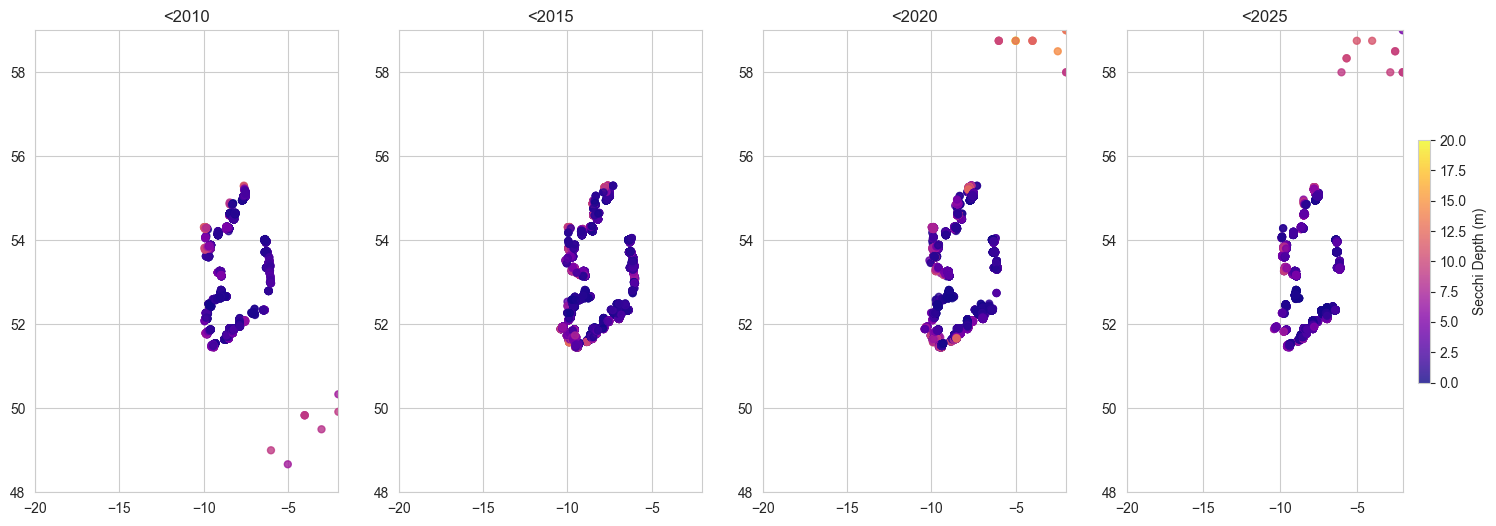

In [108]:
plt.figure(figsize=(18,6))

plt.subplot(1,4,1)

oldest = plt.scatter(
    upto2010['longitude_degE'],       # x-axis
    upto2010['latitude_degN'],        # y-axis
    c=upto2010['secchi_depth_m'],  # color by secchi depth
    cmap='plasma',
    s=25,
    alpha=0.8,
    vmin=0,
    vmax=20
)
plt.xlim(-20, -2)
plt.ylim(48, 59)
plt.title('<2010')

plt.subplot(1,4,2)
older = plt.scatter(
    upto2015['longitude_degE'],       # x-axis
    upto2015['latitude_degN'],        # y-axis
    c=upto2015['secchi_depth_m'],  # color by secchi depth
    cmap='plasma',
    s=25,
    alpha=0.8,
    vmin=0,
    vmax=20
)
plt.xlim(-20, -2)
plt.ylim(48, 59)
plt.title('<2015')

plt.subplot(1,4,3)
newer = plt.scatter(
    upto2020['longitude_degE'],       # x-axis
    upto2020['latitude_degN'],        # y-axis
    c=upto2020['secchi_depth_m'],  # color by secchi depth
    cmap='plasma',
    s=25,
    alpha=0.8,
    vmin=0,
    vmax=20
)
plt.xlim(-20, -2)
plt.ylim(48, 59)
plt.title('<2020')

plt.subplot(1,4,4)
newest = plt.scatter(
    upto2025['longitude_degE'],       # x-axis
    upto2025['latitude_degN'],        # y-axis
    c=upto2025['secchi_depth_m'],  # color by secchi depth
    cmap='plasma',
    s=25,
    alpha=0.8,
    vmin=0,
    vmax=20
)
plt.xlim(-20, -2)
plt.ylim(48, 59)
plt.title('<2025')
plt.colorbar(newest, fraction=0.04, pad=0.05, label='Secchi Depth (m)')
plt.show()


In [109]:
print(just_secchi['secchi_depth_m'].max(),just_secchi['secchi_depth_m'].min())

35.0 0.0


In [110]:
just_secchi['time'].dt.year.unique()

array([2005, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016,
       2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024], dtype=int32)

In [111]:

yearly_mean = just_secchi.groupby('year')['secchi_depth_m'].mean()
yearly_mean.all

<bound method Series.all of year
2005    7.916667
2007    2.333081
2008    1.964206
2009    2.384133
2010    3.508998
2011    3.443981
2012    3.107178
2013    2.890249
2014    2.405910
2015    2.576650
2016    2.719966
2017    2.928634
2018    2.351408
2019    2.254535
2020    2.080813
2021    2.588139
2022    2.530357
2023    2.532326
2024    9.250000
Name: secchi_depth_m, dtype: float64>

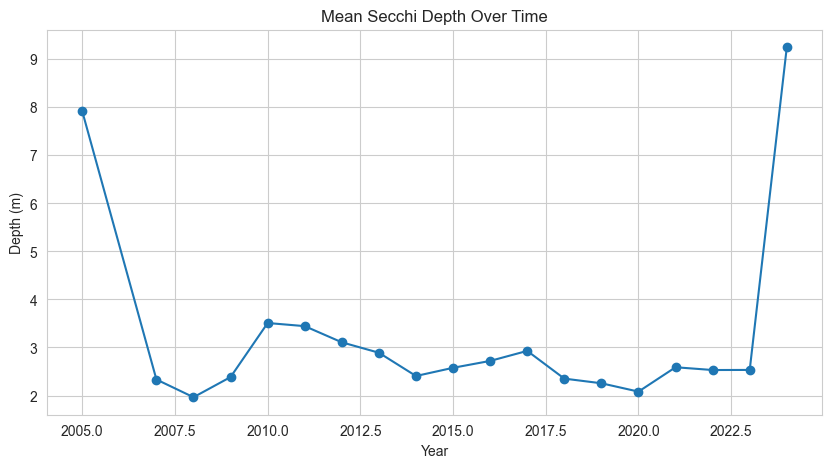

In [112]:
plt.figure(figsize=(10,5))
plt.plot(yearly_mean.index, yearly_mean.values, marker='o')
plt.xlabel('Year')
plt.ylabel('Depth (m)')
plt.title('Mean Secchi Depth Over Time')
plt.grid(True)
plt.show()

## 2024 looks so high because it is way off the coast of Ireland

In [113]:
just_secchi[just_secchi['year']==2024]
## figured out why should high depths for recent years - its all away from the coast of Ireland! need to narrow down lat/long to get coastal secchi measurements

,cruise,station,time,year,latitude_degN,longitude_degE,secchi_depth_m
19816,BSHG#2024#067I#20240723,GN045A_20240811T112400Z,2024-08-11 11:24:00+00:00,2024,58.0,-2.000000,9.0
19817,BSHG#2024#067I#20240723,GN045C_20240811T145600Z,2024-08-11 14:56:00+00:00,2024,58.0,-2.816667,9.5


## Should go through and splice down just_secchi to get a coastal_secchi, removing open ocean outliers to get a better idea of what is going on

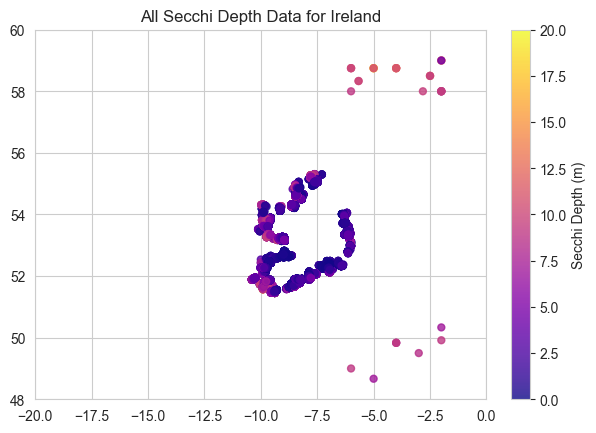

In [114]:
plt.scatter( just_secchi['longitude_degE'], just_secchi['latitude_degN'], c=just_secchi['secchi_depth_m'],
    cmap='plasma',
    s=25,
    alpha=0.8,
    vmin=0,
    vmax=20
)
plt.xlim(-20, 0)
plt.ylim(48, 60)
plt.title('All Secchi Depth Data for Ireland')


plt.colorbar( fraction=0.04, pad=0.05, label='Secchi Depth (m)')
plt.show()

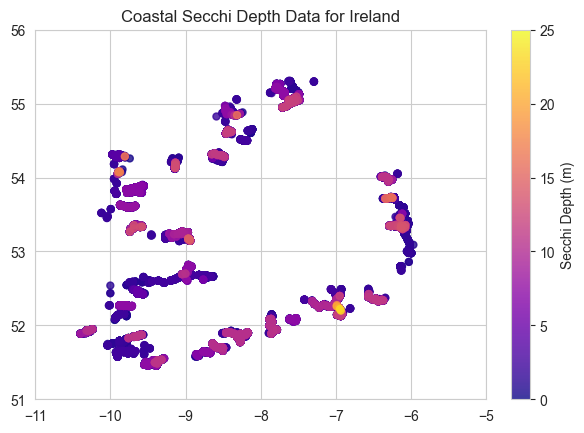

In [115]:
plt.scatter( just_secchi['longitude_degE'], just_secchi['latitude_degN'], c=just_secchi['secchi_depth_m'].sort_values(),
    cmap='plasma',
    s=25,
    alpha=0.8,
    vmin=0,
    vmax=25
)
plt.xlim(-11, -5)
plt.ylim(51, 56)
plt.title('Coastal Secchi Depth Data for Ireland')


plt.colorbar(fraction=0.04, pad=0.05, label='Secchi Depth (m)')
plt.show()

## Should use these latitude and longitude parameters for coastal secchi data

In [116]:
coastal_secchi = just_secchi[(just_secchi['longitude_degE']>=-11) & (just_secchi['longitude_degE']<=-5) & (just_secchi['latitude_degN']>=51) & (just_secchi['latitude_degN']<=56)]
coastal_secchi.describe()

,year,latitude_degN,longitude_degE,secchi_depth_m
count,19784.000000,19784.000000,19784.000000,19784.000000
mean,2014.583148,53.035297,-8.177081,2.661253
std,4.612855,1.118954,1.195521,2.334906
min,2007.000000,51.454773,-10.396320,0.000000
25%,2011.000000,51.966200,-9.137500,1.000000
50%,2014.000000,53.158300,-8.437300,1.900000
75%,2018.000000,53.974300,-7.119000,3.500000
max,2023.000000,55.311700,-5.970800,35.000000


In [117]:
coastal_med = coastal_secchi.groupby('year')['secchi_depth_m'].median()
coastal_med = coastal_med.to_frame().reset_index()
coastal_med

,year,secchi_depth_m
0,2007,1.80
1,2008,1.50
2,2009,1.60
3,2010,2.50
4,2011,2.50
5,2012,2.30
6,2013,2.00
7,2014,1.60
8,2015,1.70
9,2016,1.70


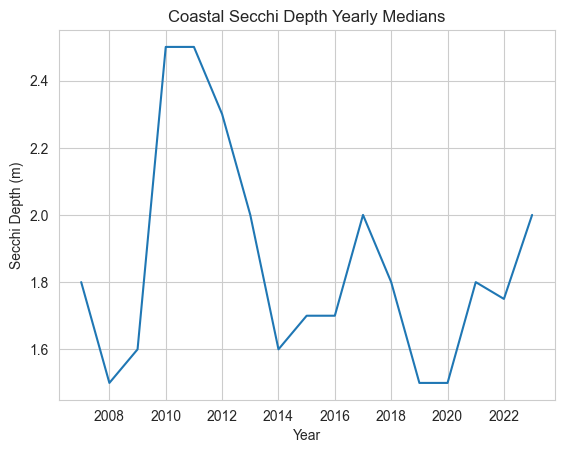

In [118]:
plt.plot( coastal_med['year'], coastal_med['secchi_depth_m'])
plt.title('Coastal Secchi Depth Yearly Medians')
plt.xlabel('Year')
plt.ylabel('Secchi Depth (m)')
plt.show()

In [119]:
## there is one value that is 35 meters, very deep for the coast, could be an outlier?
coastal_secchi[coastal_secchi['secchi_depth_m']==35]

,cruise,station,time,year,latitude_degN,longitude_degE,secchi_depth_m
2310,4599,0953,2009-05-26 09:53:00+00:00,2009,53.7955,-9.6017,35.0


In [120]:
ices_data[(ices_data['cruise']=='4599')&(ices_data['station']=='0953')]

,cruise,station,time,latitude_degN,longitude_degE,bottom_depth_m,secchi_depth_m,depth,temp_degC,salinity,...,nitrate+nitrite_umol_l,nitrate_umol_l,nitrite_umol_l,ammonium_umol_l,total_n_umol_l,pH_phunits,total_alk_meq/l,chlorophylla_ug_l,turbidity_ntu,phaeophytina_ug_l
165752,4599,0953,2007-06-18T09:53Z,54.5013,-8.1995,3.0,NaN,0.000000,14.69,8.70,...,NaN,38.6,NaN,2.9,NaN,8.00,NaN,1.99,NaN,NaN
165753,4599,0953,2007-06-18T09:53Z,54.5013,-8.1995,3.0,NaN,2.500000,13.35,30.60,...,NaN,12.1,NaN,2.1,NaN,8.00,NaN,3.00,NaN,NaN
178932,4599,0953,2008-06-11T09:53Z,51.7017,-8.5518,7.0,1.8,0.000000,15.76,29.69,...,NaN,28.7,NaN,0.7,NaN,8.35,NaN,18.90,NaN,NaN
178933,4599,0953,2008-06-11T09:53Z,51.7017,-8.5518,7.0,1.8,6.500000,14.14,32.85,...,NaN,3.0,NaN,0.7,NaN,8.15,NaN,11.80,NaN,NaN
181875,4599,0953,2008-09-08T09:53Z,55.0405,-7.5447,9.0,2.3,0.000000,NaN,NaN,...,NaN,1.4,NaN,0.7,NaN,8.00,NaN,5.00,NaN,NaN
181876,4599,0953,2008-09-08T09:53Z,55.0405,-7.5447,9.0,2.3,8.100000,15.30,31.18,...,NaN,1.4,NaN,0.7,NaN,8.00,NaN,5.00,NaN,NaN
193883,4599,0953,2009-05-26T09:53Z,53.7955,-9.6017,4.0,35.0,0.000000,12.99,32.92,...,NaN,3.6,NaN,1.1,NaN,8.20,NaN,1.00,NaN,NaN
193884,4599,0953,2009-05-26T09:53Z,53.7955,-9.6017,4.0,35.0,4.000000,12.91,33.19,...,NaN,3.6,NaN,1.1,NaN,8.20,NaN,1.00,NaN,NaN
194886,4599,0953,2009-06-30T09:53Z,55.0483,-7.4857,1.0,NaN,0.000000,19.14,33.25,...,NaN,0.7,NaN,1.4,NaN,8.20,NaN,2.00,NaN,NaN
194898,4599,0953,2009-02-18T09:53Z,55.0592,-7.5578,10.0,2.8,0.000000,6.01,30.40,...,NaN,14.3,NaN,3.6,NaN,7.80,NaN,2.00,NaN,NaN


In [121]:
coastal_secchi.sort_values(by='secchi_depth_m', ascending=False)

## went to bathymetric map, 35 meters in 2009 would have been highly unlikely unless there is a ridiculous tidal range
## same for 33 meters in 2018, it is inside the bank and shows about 8 meters

## the values in the 20s are reasonable, but stopped check after 20.5 meters in 2012.

,cruise,station,time,year,latitude_degN,longitude_degE,secchi_depth_m
2310,4599,0953,2009-05-26 09:53:00+00:00,2009,53.7955,-9.6017,35.0
14789,4599,0735,2018-07-23 09:38:00+00:00,2018,53.3565,-6.0767,33.0
6327,4599,1102,2012-05-16 11:02:00+00:00,2012,51.7578,-9.9652,20.5
3395,4599,1131,2010-02-17 11:31:00+00:00,2010,54.3033,-9.9322,20.0
11606,4599,1205,2015-08-12 13:04:00+00:00,2015,54.2970,-9.8963,18.0
...,...,...,...,...,...,...,...
13491,4599,0712,2017-06-19 09:28:00+00:00,2017,53.3317,-6.1162,0.0
2929,4599,0959,2009-08-25 09:59:00+00:00,2009,52.4748,-9.6377,0.0
16421,4599,0468,2020-07-08 12:03:00+00:00,2020,52.2770,-7.1642,0.0
7482,4599,1558,2013-02-18 15:58:00+00:00,2013,53.3535,-6.1910,0.0


In [122]:
coastal_secchi_drop = coastal_secchi[coastal_secchi['secchi_depth_m']<33]

In [123]:
coastal_secchi_drop.describe()

,year,latitude_degN,longitude_degE,secchi_depth_m
count,19782.000000,19782.000000,19782.000000,19782.000000
mean,2014.583258,53.035242,-8.177115,2.658085
std,4.612854,1.118996,1.195446,2.313640
min,2007.000000,51.454773,-10.396320,0.000000
25%,2011.000000,51.966200,-9.137500,1.000000
50%,2014.000000,53.158300,-8.437300,1.900000
75%,2018.000000,53.974300,-7.119000,3.500000
max,2023.000000,55.311700,-5.970800,20.500000


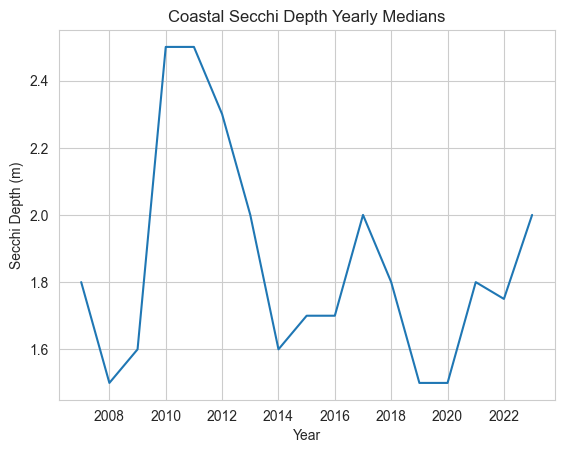

In [124]:
coastal_med_drop = coastal_secchi_drop.groupby('year')['secchi_depth_m'].median()
coastal_med_drop = coastal_med_drop.to_frame().reset_index()
coastal_med_drop
plt.plot(coastal_med_drop['year'], coastal_med_drop['secchi_depth_m'])
plt.title('Coastal Secchi Depth Yearly Medians')
plt.xlabel('Year')
plt.ylabel('Secchi Depth (m)')
plt.show()

### Big Realization! Bot. Depth== Bottom Depth! not bottle depth (stoopid) going to check to make sure its right before adding it back into just_secchi and fixing column header

In [127]:
secchi_data.groupby(['cruise','station','time','longitude_degE','latitude_degN', 'bottom_depth_m'])['secchi_depth_m'].count()
## yeah it looks right. And they usually took two measurements at each lat/long per cruise, so I shoullddd probably average them rather than just keeping the first one or keeping both measurements. I'll double check with Peter later to make sure.

cruise                                 station               time                       longitude_degE  latitude_degN  bottom_depth_m
411                                    1001-1                2022-03-02 16:36:00+00:00  -8.612848       51.722961      4.9                2
                                                             2023-02-02 14:43:00+00:00  -8.612850       51.722960      4.9                2
                                       1001-2                2022-05-16 07:26:00+00:00  -8.612848       51.722961      5.6                2
                                                             2023-06-22 09:41:00+00:00  -8.612850       51.722960      4.0                2
                                       1001-3                2022-07-06 11:53:00+00:00  -8.612848       51.722961      4.6                2
                                                                                                                                         ..
MIGR#BSHG#2005#06G2#200508

In [151]:
true_secchi = secchi_data.groupby(['cruise','station','time','latitude_degN','longitude_degE', 'bottom_depth_m'])['secchi_depth_m'].mean().reset_index()
true_secchi['year'] = true_secchi['time'].dt.year
true_secchi

,cruise,station,time,latitude_degN,longitude_degE,bottom_depth_m,secchi_depth_m,year
0,411,1001-1,2022-03-02 16:36:00+00:00,51.722961,-8.612848,4.9,0.30,2022
1,411,1001-1,2023-02-02 14:43:00+00:00,51.722960,-8.612850,4.9,2.25,2023
2,411,1001-2,2022-05-16 07:26:00+00:00,51.722961,-8.612848,5.6,1.00,2022
3,411,1001-2,2023-06-22 09:41:00+00:00,51.722960,-8.612850,4.0,1.25,2023
4,411,1001-3,2022-07-06 11:53:00+00:00,51.722961,-8.612848,4.6,1.25,2022
...,...,...,...,...,...,...,...,...
19577,MIGR#BSHG#2005#06G2#20050810#20050164,GN905_20050813T0552Z,2005-08-13 05:52:00+00:00,49.833332,-4.000000,74.0,7.00,2005
19578,MIGR#BSHG#2005#06G2#20050810#20050164,GN906_20050813T1615Z,2005-08-13 16:15:00+00:00,49.000000,-6.000000,115.0,9.00,2005
19579,MIGR#BSHG#2005#06G2#20050810#20050164,GN907_20050813T2206Z,2005-08-13 22:06:00+00:00,48.666668,-5.000000,106.0,7.00,2005
19580,MIGR#BSHG#2005#06G2#20050810#20050164,GN908_20050814T0750Z,2005-08-14 07:50:00+00:00,49.500000,-3.000000,70.0,8.50,2005


In [152]:
true_secchi[true_secchi['secchi_depth_m']>(true_secchi['bottom_depth_m']+3)]
true_secchi = true_secchi[(true_secchi['longitude_degE']>=-11) & (true_secchi['longitude_degE']<=-5) & (true_secchi['latitude_degN']>=51) & (true_secchi['latitude_degN']<=56)]
## plus 3 because maybe the bottom measurement is taken from the bottom of the boat?

In [153]:
secchi_right = true_secchi.drop(true_secchi[true_secchi['secchi_depth_m']>(true_secchi['bottom_depth_m']+3)].index)
secchi_right = secchi_right.reset_index(drop=True)
secchi_right

,cruise,station,time,latitude_degN,longitude_degE,bottom_depth_m,secchi_depth_m,year
0,411,1001-1,2022-03-02 16:36:00+00:00,51.722961,-8.612848,4.9,0.30,2022
1,411,1001-1,2023-02-02 14:43:00+00:00,51.722960,-8.612850,4.9,2.25,2023
2,411,1001-2,2022-05-16 07:26:00+00:00,51.722961,-8.612848,5.6,1.00,2022
3,411,1001-2,2023-06-22 09:41:00+00:00,51.722960,-8.612850,4.0,1.25,2023
4,411,1001-3,2022-07-06 11:53:00+00:00,51.722961,-8.612848,4.6,1.25,2022
...,...,...,...,...,...,...,...,...
19539,4599,Y100,2014-01-13 09:56:00+00:00,52.982200,-6.032500,4.0,0.90,2014
19540,4599,Y100,2014-06-19 12:29:00+00:00,52.982200,-6.032500,3.0,1.50,2014
19541,4599,Y100,2014-07-31 13:13:00+00:00,52.982200,-6.032500,4.0,3.20,2014
19542,4599,Y220,2014-05-19 13:13:00+00:00,52.346200,-6.470200,6.0,0.40,2014


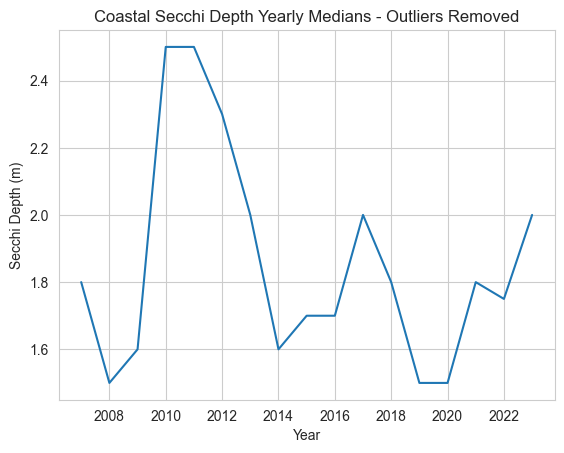

In [154]:
secchi_right_med = secchi_right.groupby('year')['secchi_depth_m'].median()
secchi_right_med = secchi_right_med.to_frame().reset_index()
secchi_right_med
plt.plot(secchi_right_med['year'], secchi_right_med['secchi_depth_m'])
plt.title('Coastal Secchi Depth Yearly Medians - Outliers Removed')
plt.xlabel('Year')
plt.ylabel('Secchi Depth (m)')
plt.show()

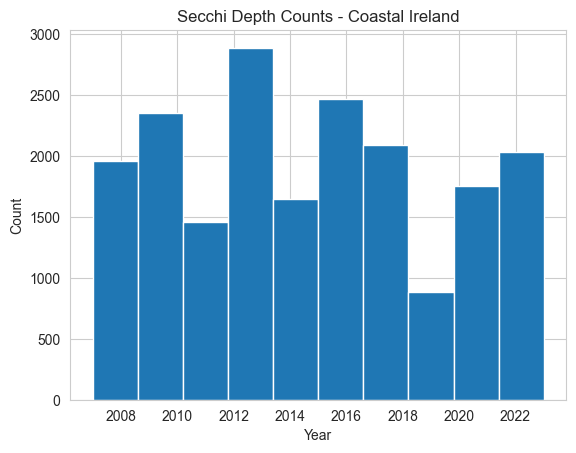

In [158]:
plt.hist(secchi_right['year'])
plt.title('Secchi Depth Counts - Coastal Ireland')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

In [160]:
secchi_right.to_csv('/Users/25298423/PycharmProjects/JupyterProject1/secchi_right.csv', index=False)
## putting this in here so that Kd490 data can be compared with Secchi data in Analysis.ipynb

### Start Here for Loading secchi_right.csv for analysis - don't have to rerun all the stuff above

In [12]:
secchi_right = pd.read_csv('/Users/25298423/PycharmProjects/JupyterProject1/secchi_right.csv')
secchi_right

,cruise,station,time,latitude_degN,longitude_degE,bottom_depth_m,secchi_depth_m,year
0,411,1001-1,2022-03-02 16:36:00+00:00,51.722961,-8.612848,4.9,0.30,2022
1,411,1001-1,2023-02-02 14:43:00+00:00,51.722960,-8.612850,4.9,2.25,2023
2,411,1001-2,2022-05-16 07:26:00+00:00,51.722961,-8.612848,5.6,1.00,2022
3,411,1001-2,2023-06-22 09:41:00+00:00,51.722960,-8.612850,4.0,1.25,2023
4,411,1001-3,2022-07-06 11:53:00+00:00,51.722961,-8.612848,4.6,1.25,2022
...,...,...,...,...,...,...,...,...
19539,4599,Y100,2014-01-13 09:56:00+00:00,52.982200,-6.032500,4.0,0.90,2014
19540,4599,Y100,2014-06-19 12:29:00+00:00,52.982200,-6.032500,3.0,1.50,2014
19541,4599,Y100,2014-07-31 13:13:00+00:00,52.982200,-6.032500,4.0,3.20,2014
19542,4599,Y220,2014-05-19 13:13:00+00:00,52.346200,-6.470200,6.0,0.40,2014


In [13]:
secchi_right.dtypes

cruise              int64
station            object
time               object
latitude_degN     float64
longitude_degE    float64
bottom_depth_m    float64
secchi_depth_m    float64
year                int64
dtype: object

In [14]:
## the "Z" at the end of the date/time tells us that is is in UTC. Keep it that way.
secchi_right['time']=pd.to_datetime(secchi_right['time'], format='mixed',utc=True)
secchi_right.dtypes

cruise                          int64
station                        object
time              datetime64[ns, UTC]
latitude_degN                 float64
longitude_degE                float64
bottom_depth_m                float64
secchi_depth_m                float64
year                            int64
dtype: object

In [15]:
secchi_right['month'] = secchi_right['time'].dt.month

In [16]:
secchi_right

,cruise,station,time,latitude_degN,longitude_degE,bottom_depth_m,secchi_depth_m,year,month
0,411,1001-1,2022-03-02 16:36:00+00:00,51.722961,-8.612848,4.9,0.30,2022,3
1,411,1001-1,2023-02-02 14:43:00+00:00,51.722960,-8.612850,4.9,2.25,2023,2
2,411,1001-2,2022-05-16 07:26:00+00:00,51.722961,-8.612848,5.6,1.00,2022,5
3,411,1001-2,2023-06-22 09:41:00+00:00,51.722960,-8.612850,4.0,1.25,2023,6
4,411,1001-3,2022-07-06 11:53:00+00:00,51.722961,-8.612848,4.6,1.25,2022,7
...,...,...,...,...,...,...,...,...,...
19539,4599,Y100,2014-01-13 09:56:00+00:00,52.982200,-6.032500,4.0,0.90,2014,1
19540,4599,Y100,2014-06-19 12:29:00+00:00,52.982200,-6.032500,3.0,1.50,2014,6
19541,4599,Y100,2014-07-31 13:13:00+00:00,52.982200,-6.032500,4.0,3.20,2014,7
19542,4599,Y220,2014-05-19 13:13:00+00:00,52.346200,-6.470200,6.0,0.40,2014,5


In [22]:
year_counts = secchi_right['year'].value_counts().sort_index()
year_counts

year
2007     901
2008    1061
2009    1103
2010    1251
2011    1460
2012    1417
2013    1474
2014    1645
2015    1321
2016    1149
2017    1137
2018     954
2019     882
2020     785
2021     971
2022    1173
2023     860
Name: count, dtype: int64

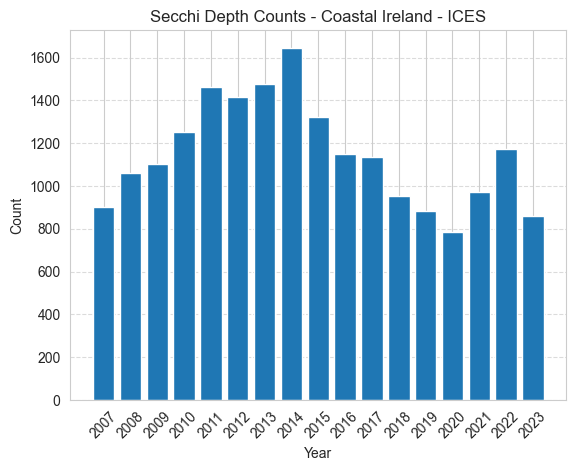

In [30]:
plt.bar(year_counts.index, year_counts.values)

plt.xticks(year_counts.index, rotation=45)

plt.title('Secchi Depth Counts - Coastal Ireland - ICES')
plt.xlabel('Year')
plt.ylabel('Count')

plt.grid(axis='y', linestyle='dashed', alpha=0.7)

plt.savefig('secchi_depth_yearly_counts.png')

plt.show()

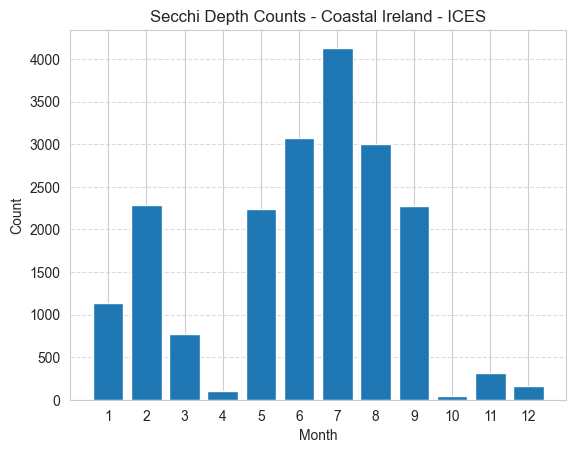

In [34]:
month_counts = secchi_right['month'].value_counts().sort_index()
month_counts

plt.bar(month_counts.index, month_counts.values)

plt.xticks(month_counts.index)

plt.title('Secchi Depth Counts - Coastal Ireland - ICES')
plt.xlabel('Month')
plt.ylabel('Count')

plt.grid(axis='y', linestyle='dashed', alpha=0.7)

plt.savefig('secchi_depth_monthly_counts.png')
plt.show()

In [37]:
## try to get this onto a map of Ireland using geopandas
## this code is the same as the one from the Analysis.ipynb (copied)
url = "https://geodata.ucdavis.edu/gadm/gadm4.1/shp/gadm41_IRL_shp.zip"
uk_url = "https://geodata.ucdavis.edu/gadm/gadm4.1/shp/gadm41_GBR_shp.zip"

ireland = gpd.read_file(url, layer="gadm41_IRL_0")

uk = gpd.read_file(uk_url, layer="gadm41_GBR_0")
uk_regions = gpd.read_file(uk_url, layer="gadm41_GBR_1")
northern_ireland = uk_regions[uk_regions["NAME_1"] == "Northern Ireland"]
island = gpd.GeoDataFrame(pd.concat([ireland, northern_ireland], ignore_index=True), crs="EPSG:4326")

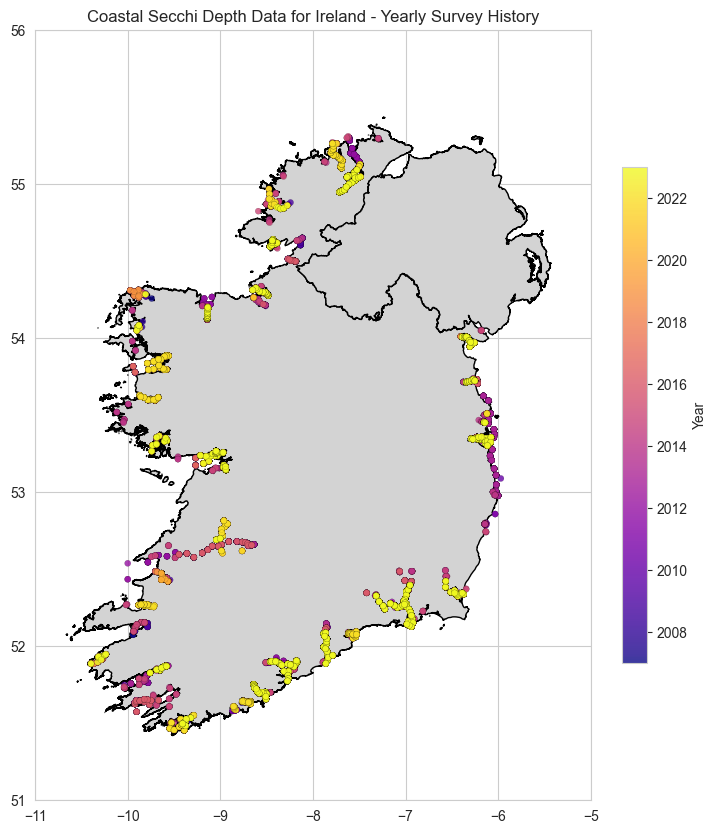

In [71]:
secchi_sort_year = secchi_right.sort_values('year', ascending=True)

center_lat = secchi_sort_year['latitude_degN'].mean()
# Calculate the aspect ratio (1 / cos(lat))
# We convert degrees to radians for the math
aspect_ratio = 1 / np.cos(np.radians(center_lat))

fig, ax = plt.subplots(figsize=(8, 10))

island.plot(ax=ax, color='lightgray', edgecolor= 'black')
sd = ax.scatter(secchi_sort_year['longitude_degE'], secchi_sort_year['latitude_degN'], c=secchi_sort_year['year'],
    cmap= 'plasma',
    alpha=0.8,
    s=20,
    edgecolor= 'black',
    linewidth= 0.1
)
ax.set_xlim(-11, -5)
ax.set_ylim(51, 56)

ax.set_aspect(aspect_ratio)

ax.set_title('Coastal Secchi Depth Data for Ireland - Yearly Survey History')

plt.colorbar(sd, ax=ax, fraction=0.04, pad=0.05, label='Year')
plt.savefig('Coastal_Secchi_Depth_Map_Yearly_Survey_History.png', dpi=600)
plt.show()

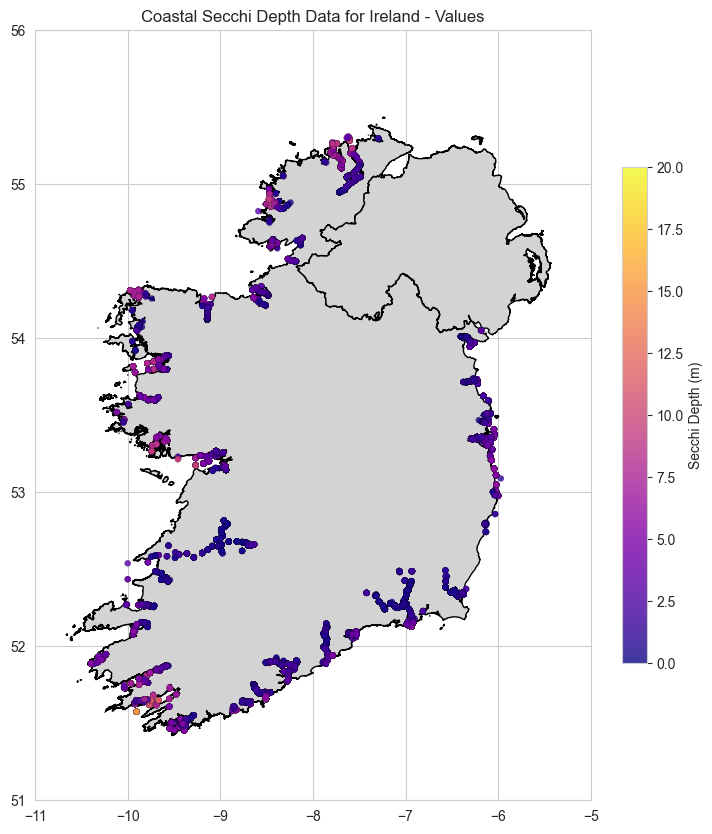

In [70]:
fig, ax = plt.subplots(figsize=(8, 10))

island.plot(ax=ax, color='lightgray', edgecolor= 'black')
sd = ax.scatter(secchi_sort_year['longitude_degE'], secchi_sort_year['latitude_degN'], c=secchi_sort_year['secchi_depth_m'],
    cmap= 'plasma',
    s=20,
    alpha=0.8,
    vmin=0,
    vmax=20,
    edgecolor= 'black',
    linewidth= 0.1
)
ax.set_xlim(-11, -5)
ax.set_ylim(51, 56)
ax.set_aspect(aspect_ratio)

ax.set_title('Coastal Secchi Depth Data for Ireland - Values')

plt.colorbar(sd, ax=ax, fraction=0.04, pad=0.05, label='Secchi Depth (m)')
plt.savefig('Coastal_Secchi_Depth_Map.png', dpi=600)
plt.show()

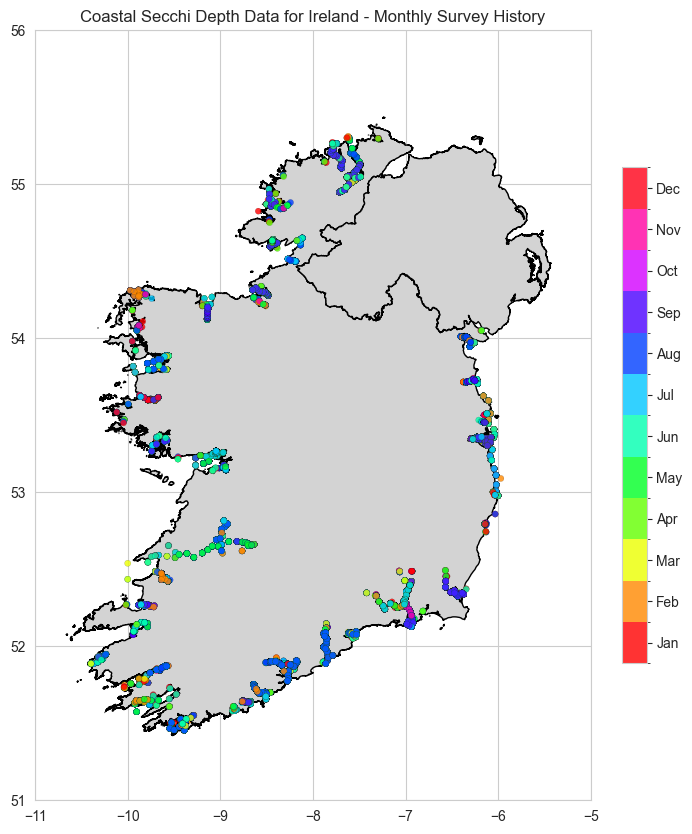

In [80]:
import matplotlib.colors as mcolors

cmap=plt.get_cmap('hsv',12)
bounds = np.arange(0.5, 13.5, 1)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(8, 10))

island.plot(ax=ax, color='lightgray', edgecolor= 'black')
sd = ax.scatter(secchi_sort_year['longitude_degE'], secchi_sort_year['latitude_degN'], c=secchi_sort_year['month'],
    cmap=cmap,
    norm=norm,
    alpha=0.8,
    s=20,
    edgecolor= 'black',
    linewidth= 0.1
)
ax.set_xlim(-11, -5)
ax.set_ylim(51, 56)

ax.set_aspect(aspect_ratio)

ax.set_title('Coastal Secchi Depth Data for Ireland - Monthly Survey History')

cbar = plt.colorbar(sd, ax=ax, fraction=0.04, pad=0.05, ticks=range(1, 13))
cbar.ax.set_yticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                         'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

plt.savefig('Coastal_Secchi_Depth_Map_Monthly_Survey_History.png', dpi=600)
plt.show()